In [1]:
# -------------------------
# Step 1: Imports & Configuration (Run First)
# -------------------------
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F  # Add this line at the top
from sklearn.metrics import mean_squared_error  # Add this line
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os

# Configuration
MOBILITY = 120  # kmph
COMPRESSION_RATIO = '1/16'
INPUT_DIM = 128   # uma128.csv has 128 columns
OUTPUT_DIM = 8    # 128 * (1/16) = 8
SEQ_LEN = 12      # From paper
PRED_LEN = 5      # From paper
EPOCHS = 150      # Extended training
BATCH_SIZE = 50
LR = 0.00005      # Reduced learning rate
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------
# Step 2: Dataset Preparation (Run Second)
# -------------------------
class CSIDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path, header=None)
        self.scaler = StandardScaler()
        self.data = self.scaler.fit_transform(self.df.values)
        
    def __len__(self):
        return len(self.data) - SEQ_LEN - PRED_LEN

    def __getitem__(self, idx):
        x = self.data[idx:idx+SEQ_LEN]
        y = self.data[idx+SEQ_LEN:idx+SEQ_LEN+PRED_LEN]
        return torch.FloatTensor(x), torch.FloatTensor(y)

# Initialize dataset and loader
dataset = CSIDataset(r"C:\Users\Aftab Dayer\Desktop\Thesis\dataset\Uma_128.csv")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# -------------------------
# Step 3: Optimized Model Architecture (Run Third)
# -------------------------
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
        
    def forward(self, h):
        # h shape: [batch, seq, features]
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)  # Now uses imported F
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))  # Fixed here

class CNNNet(nn.Module):
    def __init__(self, input_dim=128, output_dim=8):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32, output_dim)
    def forward(self, x):
        # x: [batch, seq, features] → [batch, features, seq]
        x = x.permute(0,2,1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.mean(dim=2)  # Global Average Pooling over seq length
        return self.fc(x)
        
# Instantiate


# -------------------------
# Step 4: Training Setup (Run Fourth)
# -------------------------
model = CNNNet().to(DEVICE)
optimizer = optim.RMSprop(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.MSELoss()

# -------------------------
# Step 5: Training Loop (Run Fifth)
# -------------------------
def train_model():
    metrics = {'loss': [], 'rmse': [], 'se': []}
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for x, y in loader:
            x = x.to(DEVICE)
            y = y[:, -1, :OUTPUT_DIM].to(DEVICE)  # Critical dimensional fix
            
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        rmse, se = 0, 0
        with torch.no_grad():
            for x, y in loader:
                x = x.to(DEVICE)
                y_true = y[:, -1, :OUTPUT_DIM].cpu()
                pred = model(x).cpu()
                
                rmse += np.sqrt(mean_squared_error(y_true, pred))  # Now works
                se += spectral_efficiency(y_true, pred)
        
        metrics['loss'].append(epoch_loss/len(loader))
        metrics['rmse'].append(rmse/len(loader))
        metrics['se'].append(se/len(loader))
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {metrics['loss'][-1]:.4f} | RMSE: {metrics['rmse'][-1]:.4f} | SE: {metrics['se'][-1]:.4f}")
    
    return metrics

def spectral_efficiency(y_true, y_pred, snr_db=30):
    noise_var = 10 ** (-snr_db / 10)
    signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
    interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
    sinr = signal_power / (interference + noise_var)
    return np.log2(1 + sinr)


# -------------------------
# Step 6: Execute Training (Run Sixth)
# -------------------------
print(f"\n=== Training {COMPRESSION_RATIO} Compression ===")
metrics = train_model()


=== Training 1/16 Compression ===
Epoch 1/150 | Loss: 0.7217 | RMSE: 0.7328 | SE: 0.4565
Epoch 2/150 | Loss: 0.4246 | RMSE: 0.5717 | SE: 1.2059
Epoch 3/150 | Loss: 0.2626 | RMSE: 0.4536 | SE: 2.0017
Epoch 4/150 | Loss: 0.1691 | RMSE: 0.3683 | SE: 2.6974
Epoch 5/150 | Loss: 0.1144 | RMSE: 0.3073 | SE: 3.2884
Epoch 6/150 | Loss: 0.0827 | RMSE: 0.2665 | SE: 3.7440
Epoch 7/150 | Loss: 0.0645 | RMSE: 0.2393 | SE: 4.0849
Epoch 8/150 | Loss: 0.0531 | RMSE: 0.2195 | SE: 4.3453
Epoch 9/150 | Loss: 0.0454 | RMSE: 0.2042 | SE: 4.5572
Epoch 10/150 | Loss: 0.0399 | RMSE: 0.1924 | SE: 4.7316
Epoch 11/150 | Loss: 0.0358 | RMSE: 0.1828 | SE: 4.8822
Epoch 12/150 | Loss: 0.0325 | RMSE: 0.1746 | SE: 5.0171
Epoch 13/150 | Loss: 0.0299 | RMSE: 0.1684 | SE: 5.1231
Epoch 14/150 | Loss: 0.0277 | RMSE: 0.1619 | SE: 5.2369
Epoch 15/150 | Loss: 0.0258 | RMSE: 0.1567 | SE: 5.3286
Epoch 16/150 | Loss: 0.0242 | RMSE: 0.1515 | SE: 5.4251
Epoch 17/150 | Loss: 0.0228 | RMSE: 0.1475 | SE: 5.5040
Epoch 18/150 | Loss: 0

In [ ]:
# After training:
torch.save(cnn_model.state_dict(), 'cnn_model.pth')


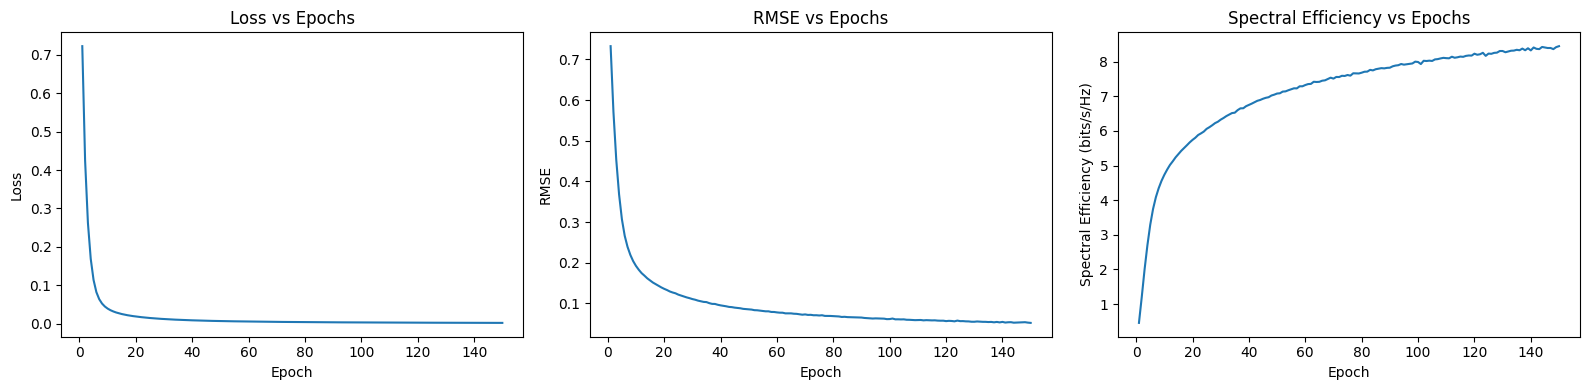

In [2]:
import pickle
import matplotlib.pyplot as plt

# SAVE metrics as a pickle file for easy loading later
with open('cnn_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
# ...similarly for CNN: cnn_metrics.pkl


# PLOT Loss, RMSE, SE vs. Epochs
epochs = range(1, len(metrics['loss'])+1)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.plot(epochs, metrics['loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, metrics['rmse'])
plt.title('RMSE vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.subplot(1,3,3)
plt.plot(epochs, metrics['se'])
plt.title('Spectral Efficiency vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Spectral Efficiency (bits/s/Hz)')

plt.tight_layout()
plt.savefig('gat_training_curves.png', dpi=300)
plt.show()


In [3]:
def evaluate_spectral_efficiency_over_ebn0(model, loader, device, ebn0_db_range):
    model.eval()
    se_list = []
    with torch.no_grad():
        for ebn0 in ebn0_db_range:
            se_sum = 0
            count = 0
            for x, y in loader:
                x = x.to(device)
                y_true = y[:, -1, :OUTPUT_DIM].cpu().numpy()
                y_pred = model(x).cpu().numpy()
                # Use current Eb/N0
                noise_var = 10 ** (-ebn0 / 10)
                signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
                interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
                sinr = signal_power / (interference + noise_var)
                se = np.log2(1 + sinr)
                se_sum += se
                count += 1
            se_list.append(se_sum / count)
    return se_list


In [4]:
import numpy as np

ebn0_db_range = np.arange(0, 21, 2)  # 0, 2, ..., 20 dB

# Assume your model is trained and loaded (CNN example here)
cnn_se_list = evaluate_spectral_efficiency_over_ebn0(model, loader, DEVICE, ebn0_db_range)


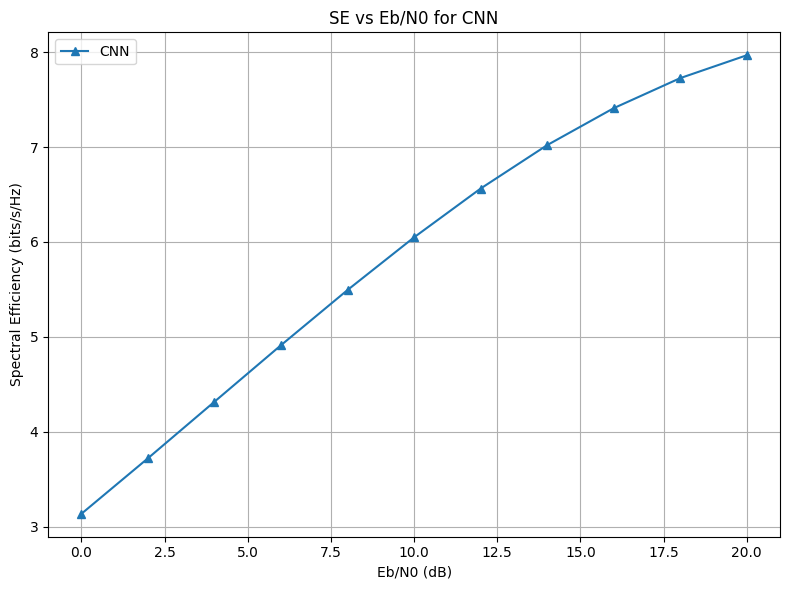

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(ebn0_db_range, cnn_se_list, marker='^', label='CNN')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Spectral Efficiency (bits/s/Hz)')
plt.title('SE vs Eb/N0 for CNN')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('cnn_se_vs_ebn0.png', dpi=300)
plt.show()


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
    def forward(self, h):
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))

class EnhancedGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GraphAttentionLayer(128, 32)
        self.gat2 = GraphAttentionLayer(128, 64)
        self.tcn = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 512),
            nn.ReLU(),
            nn.Linear(512, 8)
        )
    def forward(self, x):
        x_gat = self.gat1(x)
        x_gat = self.gat2(x_gat)
        x_tcn = self.tcn(x.permute(0,2,1))
        x_tcn = x_tcn.permute(0,2,1)
        combined = torch.cat([x_gat, x_tcn], dim=-1)
        return self.fc(combined[:, -1, :])

class LSTMNet(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=8, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = hn[-1]
        return self.fc(out)

class CNNNet(nn.Module):
    def __init__(self, input_dim=128, output_dim=8):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32, output_dim)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.mean(dim=2)
        return self.fc(x)


In [13]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gat_model = EnhancedGAT().to(DEVICE)
gat_model.load_state_dict(torch.load('gat_model.pth', map_location=DEVICE))
gat_model.eval()

lstm_model = LSTMNet().to(DEVICE)
lstm_model.load_state_dict(torch.load('lstm_model.pth', map_location=DEVICE))
lstm_model.eval()

cnn_model = CNNNet().to(DEVICE)
cnn_model.load_state_dict(torch.load('cnn_model.pth', map_location=DEVICE))
cnn_model.eval()


FileNotFoundError: [Errno 2] No such file or directory: 'gat_model.pth'